In [1]:
import json

def extract_rcsb_id(ref):
    return ref.rstrip("/").split("/")[-1].upper()

def find_site4drug_by_rcsb(json_path, rcsb_id):
    rcsb_id = rcsb_id.upper()

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for record in data:
        references = record.get("reference")

        if isinstance(references, str):
            ref_id = extract_rcsb_id(references)
            if ref_id == rcsb_id:
                return {
                    "idx": record.get("idx"),
                    "target": record.get("target"),
                    "drug": record.get("drug"),
                    "input_fasta": record.get("input_fasta"),
                    "Site4Drug_site": record.get("Site4Drug_site")
                }

        elif isinstance(references, list):
            for i, ref in enumerate(references):
                ref_id = extract_rcsb_id(ref)
                if ref_id == rcsb_id:
                    drug = record.get("drug")
                    fasta = record.get("input_fasta")
                    site = record.get("Site4Drug_site")
                    mode = record.get("mode")
                    desc = record.get("description")

                    return {
                        "idx": record.get("idx"),
                        "target": record.get("target"),
                        "matched_rcsb": rcsb_id,
                        "drug": drug[i] if isinstance(drug, list) else drug,
                        "description": desc[i] if isinstance(desc, list) else desc,
                        "mode": mode[i] if isinstance(mode, list) else mode,
                        "input_fasta": fasta[i] if isinstance(fasta, list) else fasta,
                        "Site4Drug_site": site[i] if isinstance(site, list) else site
                    }

    return None

In [2]:
result = find_site4drug_by_rcsb("Site4Drug_GroundTruth.json", "9O0R")
print(result)

{'idx': '002', 'target': 'KRAS', 'matched_rcsb': '9O0R', 'drug': 'adagrasib (MRTX849)', 'description': 'KRAS G12C inhibitor', 'mode': 'pocket', 'input_fasta': 'GMTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHHYREQIKRVKDSEDVPMVLVGNKCDLPSRTVDTKQAQDLARSYGIPFIETSAKTRQGVDDAFYTLVREIRKHKEK', 'Site4Drug_site': '5-23 | YKLVVVGAGGVGKSALTIQ  16-35 | GKSALTIQLIQNHFVDEYDP    30-50 | VDEYDPTIEDSYRKQVVIDGE   70-90 | DQYMRTGEGFLCVFAINNTKS   159-170 | TLVREIRKHKEK; top1 p-value: 0.076760044, top5 p-value: 0.894686696'}


In [4]:
import re

def extract_site_ranges(site4drug_site):
    return re.findall(r'\d+-\d+', site4drug_site)

extract_site_ranges(result['Site4Drug_site'])

['5-23', '16-35', '30-50', '70-90', '159-170']

In [13]:
import os
import re
import json
import glob
import zipfile
import tempfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio.PDB.MMCIF2Dict import MMCIF2Dict

def extract_rcsb_id(ref):
    return ref.rstrip("/").split("/")[-1].upper()

def find_site4drug_by_rcsb(json_path, rcsb_id):
    rcsb_id = rcsb_id.upper()

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for record in data:
        references = record.get("reference")

        if isinstance(references, str):
            ref_id = extract_rcsb_id(references)
            if ref_id == rcsb_id:
                return {
                    "idx": record.get("idx"),
                    "target": record.get("target"),
                    #"drug": record.get("drug"),
                    "description": record.get("description"),
                    "mode": record.get("mode"),
                    "input_fasta": record.get("input_fasta"),
                    "Site4Drug_site": record.get("Site4Drug_site")
                }

        elif isinstance(references, list):
            for i, ref in enumerate(references):
                ref_id = extract_rcsb_id(ref)
                if ref_id == rcsb_id:
                    #drug = record.get("drug")
                    fasta = record.get("input_fasta")
                    site = record.get("Site4Drug_site")
                    desc = record.get("description")
                    mode = record.get("mode")

                    return {
                        "idx": record.get("idx"),
                        "target": record.get("target"),
                        "matched_rcsb": rcsb_id,
                        #"drug": drug[i] if isinstance(drug, list) else drug,
                        "description": desc[i] if isinstance(desc, list) else desc,
                        "mode": mode[i] if isinstance(mode, list) else mode,
                        "input_fasta": fasta[i] if isinstance(fasta, list) else fasta,
                        "Site4Drug_site": site[i] if isinstance(site, list) else site
                    }

    return None

def extract_site_ranges(site4drug_site):
    if not isinstance(site4drug_site, str):
        return []
    return re.findall(r"\d+-\d+", site4drug_site)

def parse_range_string(range_string):
    start, end = range_string.split("-")
    return int(start), int(end)

def expand_ranges(range_list):
    residues = set()
    for r in range_list:
        start, end = parse_range_string(r)
        residues.update(range(start, end + 1))
    return sorted(residues)

def safe_float(x):
    try:
        return float(x)
    except:
        return np.nan

def safe_int_from_str(x):
    try:
        return int(str(x).strip())
    except:
        try:
            return int(float(x))
        except:
            return None

def load_plddt_from_cif(cif_path):
    cif = MMCIF2Dict(cif_path)

    group = cif.get("_atom_site.group_PDB", [])
    atom_name = cif.get("_atom_site.label_atom_id", [])
    asym_id = cif.get("_atom_site.label_asym_id", [])
    seq_id = cif.get("_atom_site.label_seq_id", [])
    b_iso = cif.get("_atom_site.B_iso_or_equiv", [])

    n = min(len(group), len(atom_name), len(asym_id), len(seq_id), len(b_iso))

    residue_plddt = {}
    seen = set()

    for i in range(n):
        if group[i] != "ATOM":
            continue
        if atom_name[i] != "CA":
            continue

        resi = safe_int_from_str(seq_id[i])
        if resi is None:
            continue

        key = (asym_id[i], resi)
        if key in seen:
            continue
        seen.add(key)

        residue_plddt[resi] = safe_float(b_iso[i])

    residue_numbers = sorted(residue_plddt.keys())
    plddt_values = np.array([residue_plddt[r] for r in residue_numbers], dtype=float)

    return residue_numbers, plddt_values

def zscore_array(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return np.full_like(x, np.nan, dtype=float)
    return (x - mu) / sd

def unzip_to_temp(zip_path):
    temp_dir = tempfile.mkdtemp(prefix="af3_")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(temp_dir)
    return temp_dir

def analyze_one_zip(zip_path, site4drug_json_path):
    rcsb_id = os.path.splitext(os.path.basename(zip_path))[0].upper()

    record = find_site4drug_by_rcsb(site4drug_json_path, rcsb_id)
    if record is None:
        return None, f"{rcsb_id}: not found in Site4Drug_GroundTruth.json"

    site_ranges = extract_site_ranges(record["Site4Drug_site"])
    if len(site_ranges) == 0:
        return None, f"{rcsb_id}: no valid ranges in Site4Drug_site"

    first_range = site_ranges[0]
    first_start, first_end = parse_range_string(first_range)
    first_region_residues = set(range(first_start, first_end + 1))
    all_region_residues = set(expand_ranges(site_ranges))

    extracted_dir = unzip_to_temp(zip_path)

    try:
        cif_files = sorted(
            [
                os.path.join(extracted_dir, f)
                for f in os.listdir(extracted_dir)
                if re.search(r"_model_\d+\.cif$", f)
            ]
        )

        if len(cif_files) == 0:
            return None, f"{rcsb_id}: no *_model_*.cif files"

        rows = []

        for cif_file in cif_files:
            model_match = re.search(r"_model_(\d+)\.cif$", os.path.basename(cif_file))
            model_idx = int(model_match.group(1)) if model_match else -1

            residue_numbers, plddt_values = load_plddt_from_cif(cif_file)
            z_values = zscore_array(plddt_values)

            for resi, plddt, z in zip(residue_numbers, plddt_values, z_values):
                rows.append({
                    "rcsb_id": rcsb_id,
                    "idx": record.get("idx"),
                    "target": record.get("target"),
                    #"drug": record.get("drug"),
                    "description": record.get("description"),
                    "mode": record.get("mode"),
                    "model": model_idx,
                    "residue": resi,
                    "plddt": plddt,
                    "z_plddt": z,
                    "first_range": first_range,
                    "all_ranges": ", ".join(site_ranges),
                    "in_first_region": resi in first_region_residues,
                    "in_any_region": resi in all_region_residues
                })

        df = pd.DataFrame(rows)

        df_first = df[df["in_first_region"]].copy()
        df_all_regions = df[df["in_any_region"]].copy()

        summary_rows = [
            {
                "rcsb_id": rcsb_id,
                "idx": record.get("idx"),
                "target": record.get("target"),
                #"drug": record.get("drug"),
                "group": "first_region",
                "range_info": first_range,
                "n_values": len(df_first),
                "mean_z": df_first["z_plddt"].mean(),
                "std_z": df_first["z_plddt"].std(),
                "median_z": df_first["z_plddt"].median(),
                "min_z": df_first["z_plddt"].min(),
                "max_z": df_first["z_plddt"].max()
            },
            {
                "rcsb_id": rcsb_id,
                "idx": record.get("idx"),
                "target": record.get("target"),
                #"drug": record.get("drug"),
                "group": "all_regions",
                "range_info": ", ".join(site_ranges),
                "n_values": len(df_all_regions),
                "mean_z": df_all_regions["z_plddt"].mean(),
                "std_z": df_all_regions["z_plddt"].std(),
                "median_z": df_all_regions["z_plddt"].median(),
                "min_z": df_all_regions["z_plddt"].min(),
                "max_z": df_all_regions["z_plddt"].max()
            }
        ]
        summary_df = pd.DataFrame(summary_rows)

        return {
            "record": record,
            "site_ranges": site_ranges,
            "first_range": first_range,
            "df_all": df,
            "df_first": df_first,
            "df_all_regions": df_all_regions,
            "summary": summary_df
        }, None

    finally:
        shutil.rmtree(extracted_dir, ignore_errors=True)

def analyze_all_af3_zips(alphafold3_dir, site4drug_json_path, output_dir="./af3_site4drug_results"):
    os.makedirs(output_dir, exist_ok=True)

    zip_files = sorted(glob.glob(os.path.join(alphafold3_dir, "*.zip")))

    if len(zip_files) == 0:
        raise ValueError(f"No zip files found in {alphafold3_dir}")

    all_df_list = []
    first_df_list = []
    all_regions_df_list = []
    summary_list = []
    errors = []

    for zip_path in zip_files:
        result, err = analyze_one_zip(zip_path, site4drug_json_path)

        if err is not None:
            errors.append({"zip_file": os.path.basename(zip_path), "error": err})
            continue

        all_df_list.append(result["df_all"])
        first_df_list.append(result["df_first"])
        all_regions_df_list.append(result["df_all_regions"])
        summary_list.append(result["summary"])

    if len(all_df_list) == 0:
        raise ValueError("No valid zip files were analyzed successfully")

    df_all = pd.concat(all_df_list, ignore_index=True)
    df_first = pd.concat(first_df_list, ignore_index=True)
    df_all_regions = pd.concat(all_regions_df_list, ignore_index=True)
    summary_df = pd.concat(summary_list, ignore_index=True)
    error_df = pd.DataFrame(errors)

    df_all.to_csv(os.path.join(output_dir, "all_residue_zscores.csv"), index=False)
    df_first.to_csv(os.path.join(output_dir, "first_region_residue_zscores.csv"), index=False)
    df_all_regions.to_csv(os.path.join(output_dir, "all_regions_residue_zscores.csv"), index=False)
    summary_df.to_csv(os.path.join(output_dir, "summary_by_rcsb.csv"), index=False)

    if len(error_df) > 0:
        error_df.to_csv(os.path.join(output_dir, "errors.csv"), index=False)

    return {
        "df_all": df_all,
        "df_first": df_first,
        "df_all_regions": df_all_regions,
        "summary": summary_df,
        "errors": error_df,
        "output_dir": output_dir
    }

def plot_global_boxplot(summary_result):
    df_first = summary_result["df_first"]
    df_all_regions = summary_result["df_all_regions"]

    plt.figure(figsize=(8, 6))
    data_to_plot = [
        df_first["z_plddt"].dropna().values,
        df_all_regions["z_plddt"].dropna().values
    ]
    plt.boxplot(data_to_plot, labels=["First region", "All Site4Drug regions"])
    plt.ylabel("z-scored pLDDT")
    plt.title("All AF3 zip files: z-scored pLDDT comparison")
    plt.tight_layout()
    plt.show()

def plot_global_violin(summary_result):
    df_first = summary_result["df_first"].copy()
    df_all_regions = summary_result["df_all_regions"].copy()

    plt.figure(figsize=(8, 6))
    data_to_plot = [
        df_first["z_plddt"].dropna().values,
        df_all_regions["z_plddt"].dropna().values
    ]
    plt.violinplot(data_to_plot, showmeans=True, showmedians=True)
    plt.xticks([1, 2], ["First region", "All Site4Drug regions"])
    plt.ylabel("z-scored pLDDT")
    plt.title("All AF3 zip files: z-scored pLDDT distribution")
    plt.tight_layout()
    plt.show()

def plot_summary_scatter(summary_result):
    summary_df = summary_result["summary"]

    first_summary = summary_df[summary_df["group"] == "first_region"].copy()
    all_summary = summary_df[summary_df["group"] == "all_regions"].copy()

    merged = first_summary.merge(
        all_summary,
        on=["rcsb_id", "idx", "target"],
        suffixes=("_first", "_all")
    )

    plt.figure(figsize=(8, 6))
    plt.scatter(merged["mean_z_first"], merged["mean_z_all"])
    for _, row in merged.iterrows():
        plt.text(row["mean_z_first"], row["mean_z_all"], row["rcsb_id"], fontsize=8)

    min_val = np.nanmin([merged["mean_z_first"].min(), merged["mean_z_all"].min()])
    max_val = np.nanmax([merged["mean_z_first"].max(), merged["mean_z_all"].max()])
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Mean z-scored pLDDT of first region")
    plt.ylabel("Mean z-scored pLDDT of all regions")
    plt.title("Per-RCSB comparison")
    plt.tight_layout()
    plt.show()

def plot_per_target_means(summary_result, top_n=30):
    summary_df = summary_result["summary"]

    agg = summary_df.groupby(["target", "group"])["mean_z"].mean().reset_index()
    target_order = (
        agg.groupby("target")["mean_z"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    agg = agg[agg["target"].isin(target_order)].copy()

    first_vals = agg[agg["group"] == "first_region"].set_index("target")["mean_z"]
    all_vals = agg[agg["group"] == "all_regions"].set_index("target")["mean_z"]

    x = np.arange(len(target_order))
    width = 0.4

    plt.figure(figsize=(max(10, len(target_order) * 0.4), 6))
    plt.bar(x - width/2, [first_vals.get(t, np.nan) for t in target_order], width=width, label="First region")
    plt.bar(x + width/2, [all_vals.get(t, np.nan) for t in target_order], width=width, label="All regions")
    plt.xticks(x, target_order, rotation=90)
    plt.ylabel("Mean z-scored pLDDT")
    plt.title("Mean z-scored pLDDT by target")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
result = analyze_all_af3_zips(
    alphafold3_dir="./AlphaFold3",
    site4drug_json_path="./Site4Drug_GroundTruth.json",
    output_dir="./af3_site4drug_results"
)

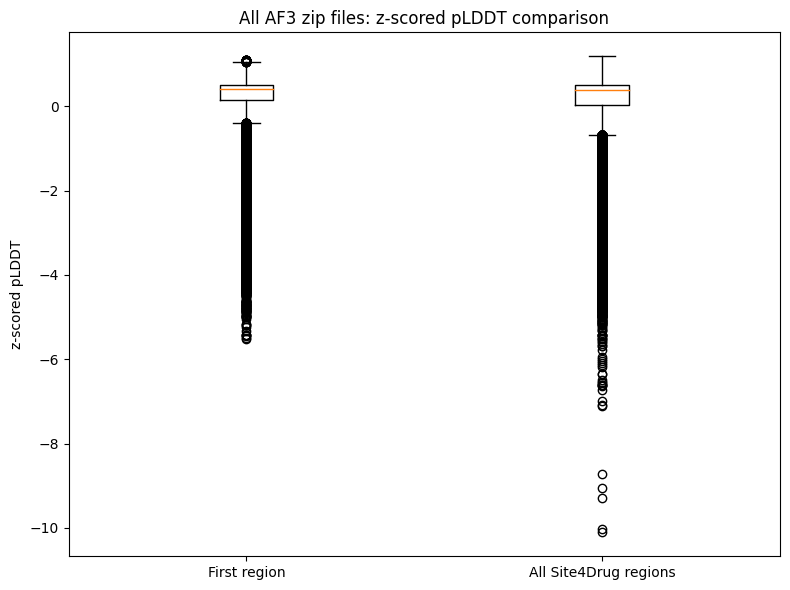

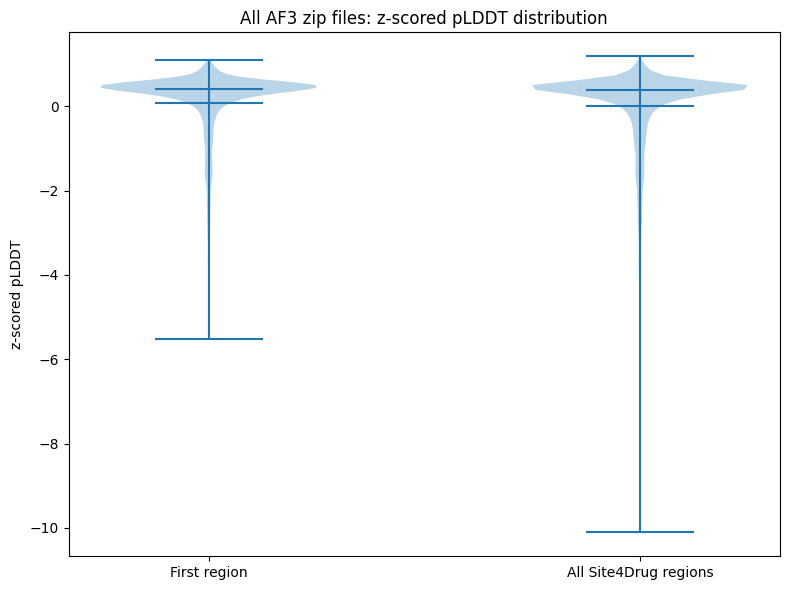

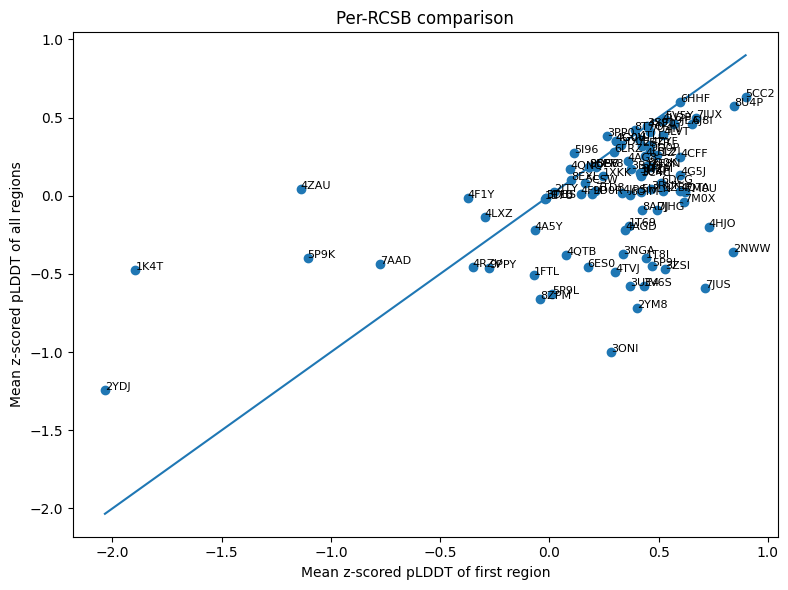

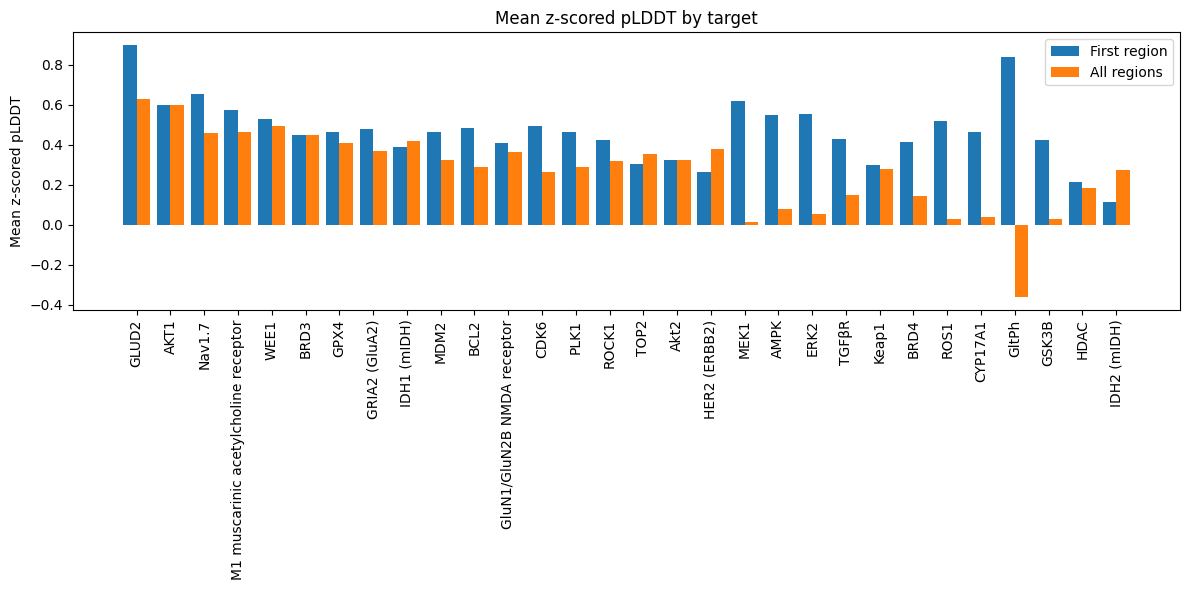

In [17]:
plot_global_boxplot(result)
plot_global_violin(result)
plot_summary_scatter(result)
plot_per_target_means(result, top_n=30)

In [5]:
import os
import re
import json
import glob
import zipfile
import tempfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio.PDB.MMCIF2Dict import MMCIF2Dict

def extract_rcsb_id(ref):
    return ref.rstrip("/").split("/")[-1].upper()

def extract_site_ranges(site4drug_site):
    if not isinstance(site4drug_site, str):
        return []
    return re.findall(r"\d+-\d+", site4drug_site)

def parse_range_string(range_string):
    start, end = range_string.split("-")
    return int(start), int(end)

def expand_ranges(range_list):
    residues = set()
    for r in range_list:
        start, end = parse_range_string(r)
        residues.update(range(start, end + 1))
    return sorted(residues)

def safe_float(x):
    try:
        return float(x)
    except:
        return np.nan

def safe_int_from_str(x):
    try:
        return int(str(x).strip())
    except:
        try:
            return int(float(x))
        except:
            return None

def load_plddt_from_cif(cif_path):
    cif = MMCIF2Dict(cif_path)

    group = cif.get("_atom_site.group_PDB", [])
    atom_name = cif.get("_atom_site.label_atom_id", [])
    asym_id = cif.get("_atom_site.label_asym_id", [])
    seq_id = cif.get("_atom_site.label_seq_id", [])
    b_iso = cif.get("_atom_site.B_iso_or_equiv", [])

    n = min(len(group), len(atom_name), len(asym_id), len(seq_id), len(b_iso))

    residue_plddt = {}
    seen = set()

    for i in range(n):
        if group[i] != "ATOM":
            continue
        if atom_name[i] != "CA":
            continue

        resi = safe_int_from_str(seq_id[i])
        if resi is None:
            continue

        key = (asym_id[i], resi)
        if key in seen:
            continue
        seen.add(key)

        residue_plddt[resi] = safe_float(b_iso[i])

    residue_numbers = sorted(residue_plddt.keys())
    plddt_values = np.array([residue_plddt[r] for r in residue_numbers], dtype=float)
    return residue_numbers, plddt_values

def unzip_to_temp(zip_path):
    temp_dir = tempfile.mkdtemp(prefix="af3_")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(temp_dir)
    return temp_dir

def parse_idx_seq(label):
    m = re.match(r"idx(\d+)\.seq(\d+)$", label.strip())
    if not m:
        raise ValueError(f"Invalid label format: {label}")
    idx = m.group(1)
    seq = int(m.group(2))
    return idx, seq

def load_site4drug_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

def find_record_by_idx(data, idx_string):
    for record in data:
        if str(record.get("idx", "")).zfill(3) == str(idx_string).zfill(3):
            return record
    return None

def get_seq_specific_fields(record, seq_idx):
    refs = record.get("reference")
    fasta = record.get("input_fasta")
    site = record.get("Site4Drug_site")
    drug = record.get("drug")
    desc = record.get("description")
    mode = record.get("mode")

    if isinstance(refs, list):
        ref_val = refs[seq_idx]
    else:
        if seq_idx != 0:
            raise IndexError(f"idx{record['idx']} has only one sequence, but seq{seq_idx} requested")
        ref_val = refs

    if isinstance(fasta, list):
        fasta_val = fasta[seq_idx]
    else:
        fasta_val = fasta

    if isinstance(site, list):
        site_val = site[seq_idx]
    else:
        site_val = site

    if isinstance(drug, list):
        drug_val = drug[seq_idx]
    else:
        drug_val = drug

    if isinstance(desc, list):
        desc_val = desc[seq_idx]
    else:
        desc_val = desc

    if isinstance(mode, list):
        mode_val = mode[seq_idx]
    else:
        mode_val = mode

    return {
        "reference": ref_val,
        "rcsb_id": extract_rcsb_id(ref_val),
        "input_fasta": fasta_val,
        "Site4Drug_site": site_val,
        "drug": drug_val,
        "description": desc_val,
        "mode": mode_val
    }

def summarize_one_entry(label, alphafold3_dir, site4drug_json_path):
    idx_str, seq_idx = parse_idx_seq(label)
    data = load_site4drug_json(site4drug_json_path)
    record = find_record_by_idx(data, idx_str)

    if record is None:
        raise ValueError(f"{label}: idx{idx_str} not found in JSON")

    fields = get_seq_specific_fields(record, seq_idx)
    rcsb_id = fields["rcsb_id"]

    zip_path = os.path.join(alphafold3_dir, f"{rcsb_id}.zip")
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"{label}: zip file not found: {zip_path}")

    site_ranges = extract_site_ranges(fields["Site4Drug_site"])
    if len(site_ranges) == 0:
        raise ValueError(f"{label}: no valid site ranges")

    best_range = site_ranges[0]
    best_start, best_end = parse_range_string(best_range)
    best_residues = set(range(best_start, best_end + 1))
    all_residues = set(expand_ranges(site_ranges))

    extracted_dir = unzip_to_temp(zip_path)

    try:
        cif_files = sorted(
            [
                os.path.join(extracted_dir, f)
                for f in os.listdir(extracted_dir)
                if re.search(r"_model_\d+\.cif$", f)
            ]
        )

        if len(cif_files) == 0:
            raise ValueError(f"{label}: no *_model_*.cif files in zip")

        all_model_values = []
        best_site_means = []
        all_site_means = []

        for cif_file in cif_files:
            residue_numbers, plddt_values = load_plddt_from_cif(cif_file)

            all_model_values.extend(plddt_values.tolist())

            res_to_plddt = dict(zip(residue_numbers, plddt_values))

            best_vals = [res_to_plddt[r] for r in sorted(best_residues) if r in res_to_plddt and not np.isnan(res_to_plddt[r])]
            all_vals = [res_to_plddt[r] for r in sorted(all_residues) if r in res_to_plddt and not np.isnan(res_to_plddt[r])]

            best_site_means.append(np.mean(best_vals) if len(best_vals) > 0 else np.nan)
            all_site_means.append(np.mean(all_vals) if len(all_vals) > 0 else np.nan)

        return {
            "label": label,
            "idx": str(record["idx"]).zfill(3),
            "seq_idx": seq_idx,
            "target": record.get("target"),
            "drug": fields["drug"],
            "rcsb_id": rcsb_id,
            "best_range": best_range,
            "all_ranges": site_ranges,
            "all_plddt_values": np.array(all_model_values, dtype=float),
            "best_site_mean_plddt": np.nanmean(best_site_means),
            "all_site_mean_plddt": np.nanmean(all_site_means),
            "n_models": len(cif_files)
        }

    finally:
        shutil.rmtree(extracted_dir, ignore_errors=True)

def build_entry_summary(labels, alphafold3_dir, site4drug_json_path):
    rows = []
    errors = []

    for label in labels:
        try:
            row = summarize_one_entry(label, alphafold3_dir, site4drug_json_path)
            rows.append(row)
        except Exception as e:
            errors.append({"label": label, "error": str(e)})

    return rows, pd.DataFrame(errors)

def plot_top_to_bottom_distributions(entry_rows, use="best", figsize_per_row=0.55, save_path=None):
    if use not in ["best", "all"]:
        raise ValueError("use must be 'best' or 'all'")

    if len(entry_rows) == 0:
        raise ValueError("No valid entries to plot")

    if use == "best":
        xmean_key = "best_site_mean_plddt"
        title = "pLDDT distribution with best-site mean"
        mean_label = "Best-site mean"
    else:
        xmean_key = "all_site_mean_plddt"
        title = "pLDDT distribution with all-site mean"
        mean_label = "All-site mean"

    n = len(entry_rows)
    fig_h = max(6, n * figsize_per_row)
    fig, ax = plt.subplots(figsize=(10, fig_h))

    y_positions = np.arange(n, 0, -1)

    for y, row in zip(y_positions, entry_rows):
        vals = row["all_plddt_values"]
        vals = vals[~np.isnan(vals)]

        vp = ax.violinplot(
            [vals],
            positions=[y],
            vert=False,
            widths=0.8,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )

        mean_x = row[xmean_key]
        if not np.isnan(mean_x):
            ax.scatter(mean_x, y, s=40, zorder=3)

    ylabels = [
        f"{row['label']} | {row['rcsb_id']} | {row['target']}"
        for row in entry_rows
    ]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(ylabels)
    ax.set_xlabel("pLDDT")
    ax.set_title(title)
    ax.set_xlim(0, 100)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', linestyle='None', markersize=6, label=mean_label)
    ]
    ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def make_summary_dataframe(entry_rows):
    return pd.DataFrame([
        {
            "label": row["label"],
            "idx": row["idx"],
            "seq_idx": row["seq_idx"],
            "target": row["target"],
            "drug": row["drug"],
            "rcsb_id": row["rcsb_id"],
            "best_range": row["best_range"],
            "all_ranges": ", ".join(row["all_ranges"]),
            "best_site_mean_plddt": row["best_site_mean_plddt"],
            "all_site_mean_plddt": row["all_site_mean_plddt"],
            "n_models": row["n_models"]
        }
        for row in entry_rows
    ])
labels = [
"idx001.seq0",
"idx002.seq0",
"idx002.seq1",
"idx003.seq0",
"idx005.seq1",
"idx007.seq0",
"idx007.seq1",
"idx007.seq2",
"idx008.seq0",
"idx009.seq0",
"idx009.seq1",
"idx010.seq0",
"idx011.seq0",
"idx012.seq0",
"idx013.seq0",
"idx014.seq0",
"idx014.seq1",
"idx015.seq0",
"idx016.seq0",
"idx017.seq0",
"idx018.seq0",
"idx019.seq0",
"idx020.seq0",
"idx021.seq0",
"idx022.seq0",
"idx023.seq0",
"idx025.seq0",
"idx026.seq3",
"idx029.seq0",
"idx030.seq0",
"idx031.seq0",
"idx032.seq0",
"idx033.seq3",
"idx034.seq0",
"idx035.seq0",
"idx038.seq1",
"idx039.seq0",
"idx042.seq0",
"idx042.seq1",
"idx043.seq0",
"idx044.seq0",
"idx045.seq0",
"idx047.seq0",
"idx048.seq0",
"idx048.seq1",
"idx048.seq2",
"idx049.seq0",
"idx050.seq0",
"idx050.seq1",
"idx051.seq0",
"idx053.seq0",
"idx054.seq0",
"idx055.seq0",
"idx056.seq0",
"idx057.seq0",
"idx201.seq0",
"idx201.seq1",
"idx201.seq2",
"idx201.seq4",
"idx201.seq5",
"idx202.seq0",
"idx202.seq1",
"idx203.seq0"
]

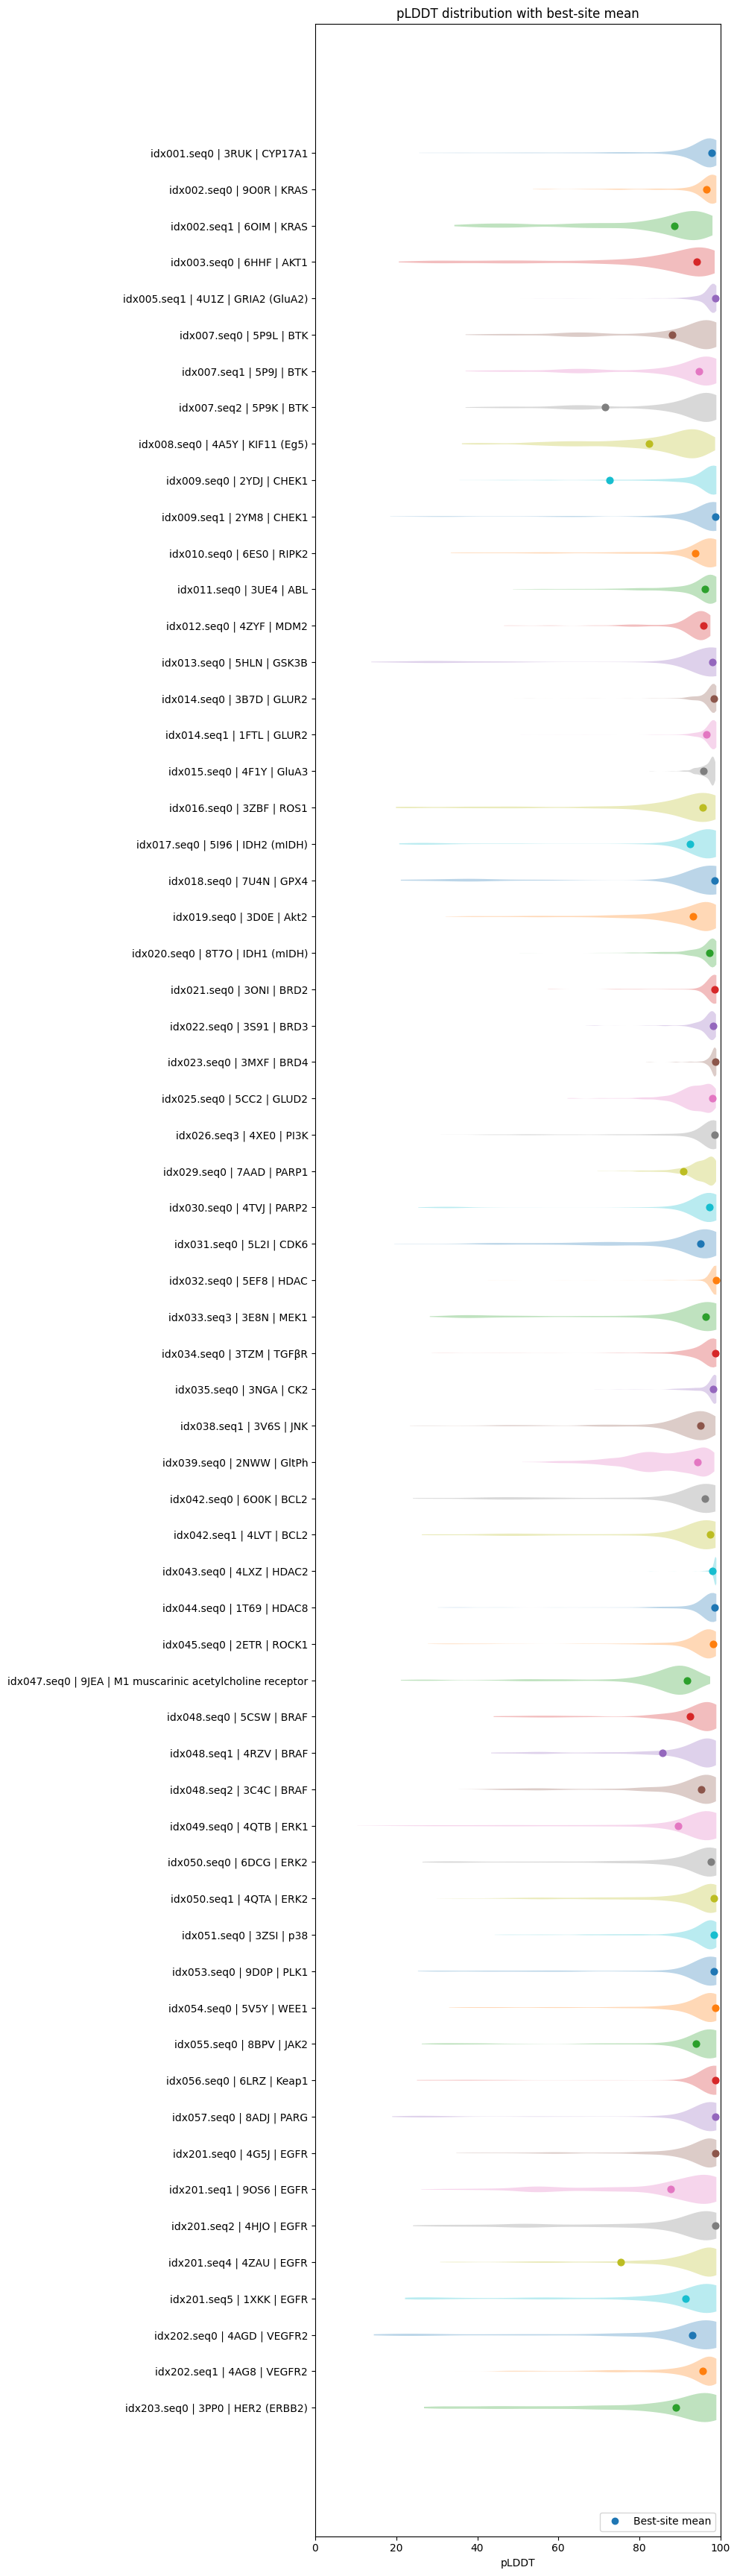

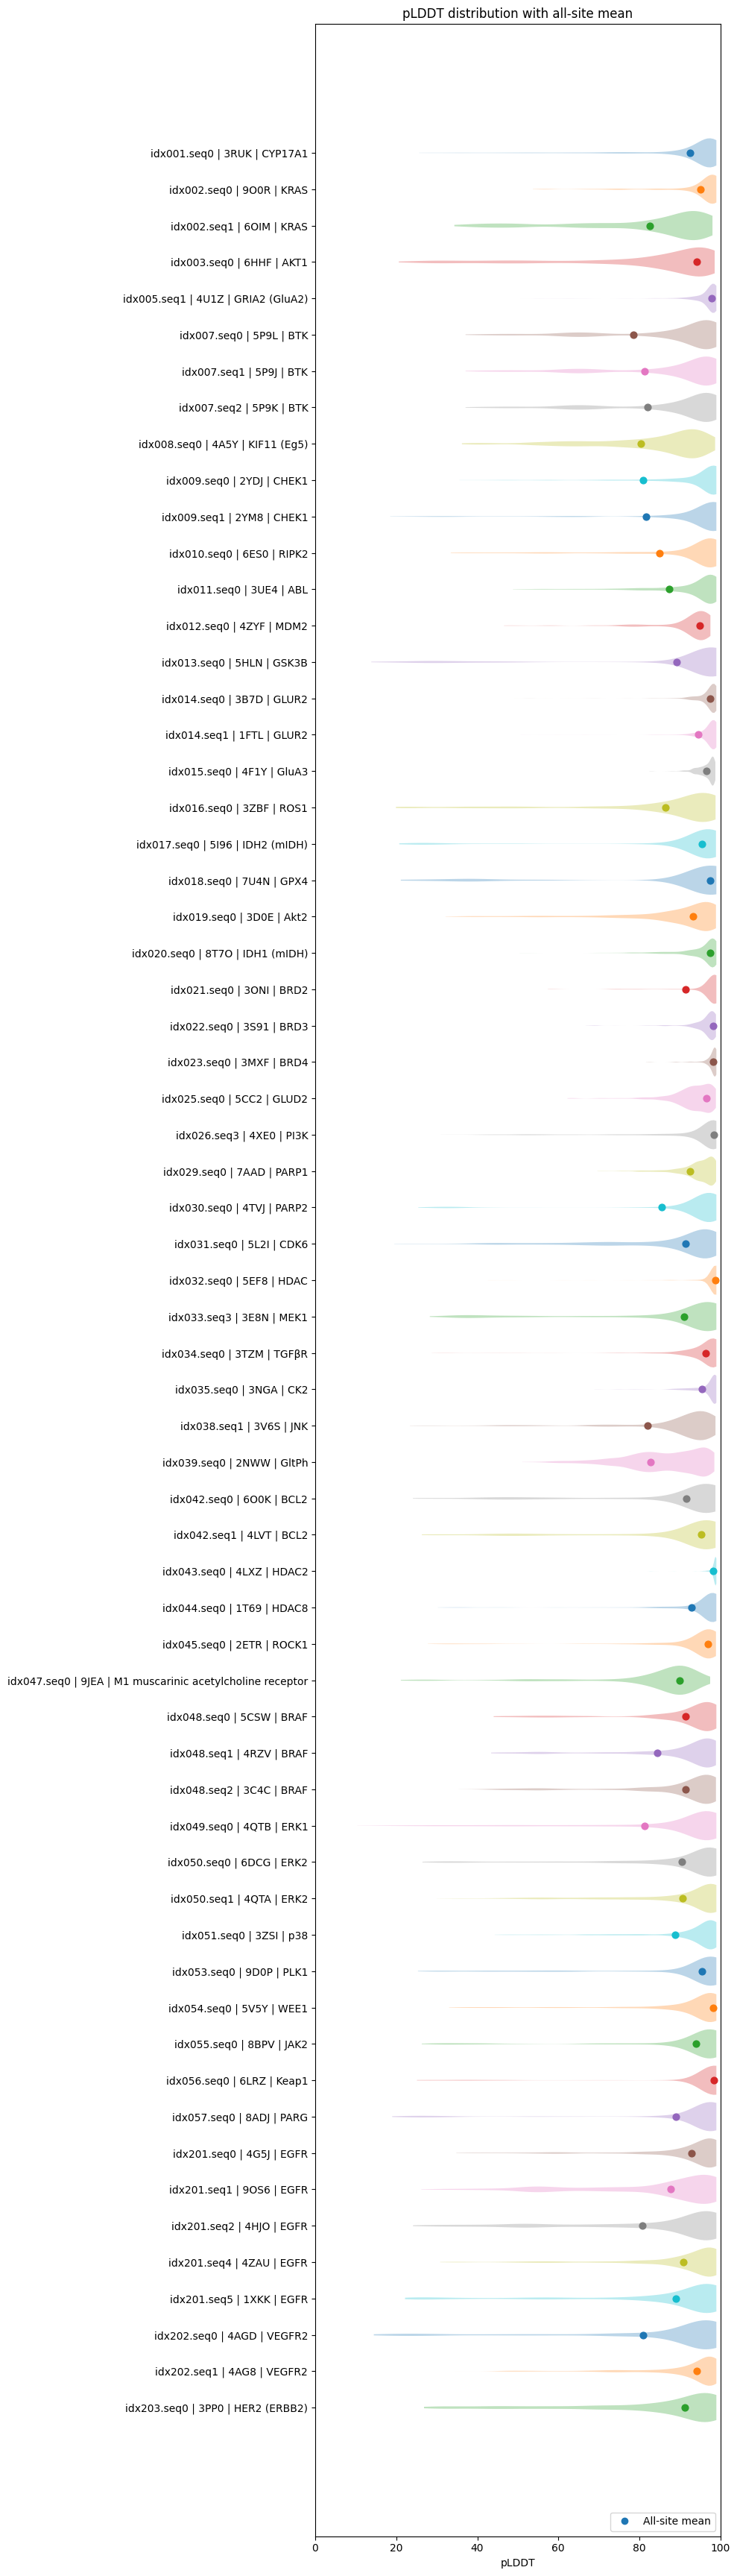

In [6]:
entry_rows, error_df = build_entry_summary(
    labels=labels,
    alphafold3_dir="./AlphaFold3",
    site4drug_json_path="./Site4Drug_GroundTruth.json"
)

plot_top_to_bottom_distributions(
    entry_rows,
    use="best",
    save_path="./best_site_plddt_distribution.png"
)

plot_top_to_bottom_distributions(
    entry_rows,
    use="all",
    save_path="./all_sites_plddt_distribution.png"
)

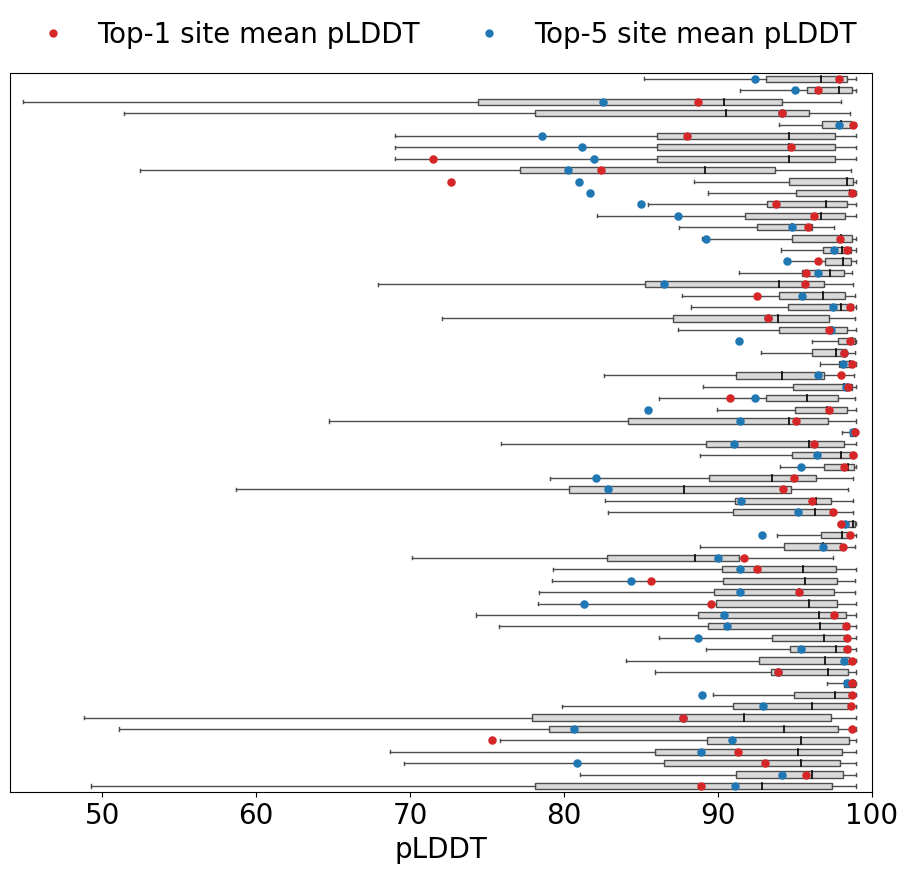

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_combined_horizontal_boxplot(
    entry_rows,
    figsize=(10, 12),
    box_height=0.55,
    top_color="#d62728",
    all_color="#1f77b4",
    distribution_facecolor="#d9d9d9",
    distribution_edgecolor="#4d4d4d",
    save_path=None
):
    if len(entry_rows) == 0:
        raise ValueError("No valid entries to plot")

    n = len(entry_rows)
    y_positions = np.arange(n, 0, -1)

    fig, ax = plt.subplots(figsize=figsize)

    data_to_plot = []
    for row in entry_rows:
        vals = np.asarray(row["all_plddt_values"], dtype=float)
        vals = vals[~np.isnan(vals)]
        data_to_plot.append(vals)

    bp = ax.boxplot(
        data_to_plot,
        vert=False,
        positions=y_positions,
        widths=box_height,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color=distribution_edgecolor, linewidth=1.0),
        capprops=dict(color=distribution_edgecolor, linewidth=1.0),
        boxprops=dict(edgecolor=distribution_edgecolor, linewidth=1.0),
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(distribution_facecolor)
        patch.set_alpha(1.0)

    best_x = [row["best_site_mean_plddt"] for row in entry_rows]
    all_x = [row["all_site_mean_plddt"] for row in entry_rows]

    ax.scatter(
        all_x,
        y_positions,
        s=26,
        color=all_color,
        zorder=3,
        label="All-site mean pLDDT"
    )

    ax.scatter(
        best_x,
        y_positions,
        s=26,
        color=top_color,
        zorder=3,
        label="Top-site mean pLDDT"
    )

    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("pLDDT")
    ax.set_xlim(44, 100)
    #ax.set_title("Per-entry pLDDT distribution with top-site and all-site means")

    legend_elements = [
        #Line2D([0], [0], color=distribution_edgecolor, lw=8, solid_capstyle="butt",
        #       label="Whole-structure pLDDT distribution"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=top_color,
               markersize=7, label="Top-1 site mean pLDDT"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=all_color,
               markersize=7, label="Top-5 site mean pLDDT"),
    ]
    
    ax.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=2,
        frameon=False,
        columnspacing=1.5,
        handletextpad=0.6,
        labelspacing=0.8,
        borderaxespad=0.8
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

plt.rc('font', size = 20)
plot_combined_horizontal_boxplot(
    entry_rows,
    figsize=(10, 10),
    save_path="./combined_boxplot2.png"
)